<a href="https://colab.research.google.com/github/stephenchen0814/04-LinearReg_Salary/blob/main/Random%20Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset=datasets.load_iris()
X = dataset.data
y = dataset.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [4]:
rf_classifier = RandomForestClassifier(n_estimators=10,
                                       criterion='gini',
                                       max_samples=int(X_train.shape[0]*0.8),
                                       min_impurity_decrease=0.1,
                                       max_depth=3,
                                       max_features=None,
                                       oob_score=True,
                                       random_state=42)

In [5]:
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, max_features=None, max_samples=96,
                       min_impurity_decrease=0.1, n_estimators=10,
                       oob_score=True, random_state=42)

In [6]:
y_pred = rf_classifier.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
oob_score = rf_classifier.oob_score_
print(f'Out-of-Bag Score: {oob_score:.2f}')

Accuracy: 1.00
Out-of-Bag Score: 0.93


In [8]:
rf_classifier.predict_proba(X_test[1].reshape(1,-1))

array([[0.        , 0.04886752, 0.95113248]])

In [9]:
y_test[1]

np.int64(2)

In [10]:
rf_classifier2 = RandomForestClassifier(n_estimators=10,
                                       criterion='gini',
                                       max_samples=int(X_train.shape[0]*0.8),
                                       min_impurity_decrease=0.1,
                                       max_depth=3,
                                       max_features=2,
                                       oob_score=True,
                                       random_state=42)

In [11]:
rf_classifier2.fit(X_train, y_train)
y_pred2 = rf_classifier2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
oob_score = rf_classifier.oob_score_
print(f'Out-of-Bag Score: {oob_score:.2f}')

Accuracy: 1.00
Out-of-Bag Score: 0.93


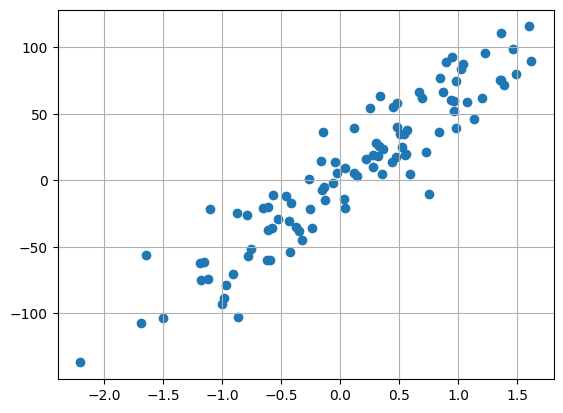

In [12]:
X, y = datasets.make_regression(n_samples=100, n_features=1, noise=20)

fig=plt.figure()
plt.grid()

plt.scatter(X,y)

In [13]:
rf_regressor=RandomForestRegressor(n_estimators=10,
                                   max_samples=int(X_train.shape[0]*0.8),
                                   min_impurity_decrease=0.1,
                                   max_depth=3,
                                   oob_score=True,
                                   random_state=42)

In [14]:
rf_regressor.fit(X, y)

RandomForestRegressor(max_depth=3, max_samples=96, min_impurity_decrease=0.1,
                      n_estimators=10, oob_score=True, random_state=42)

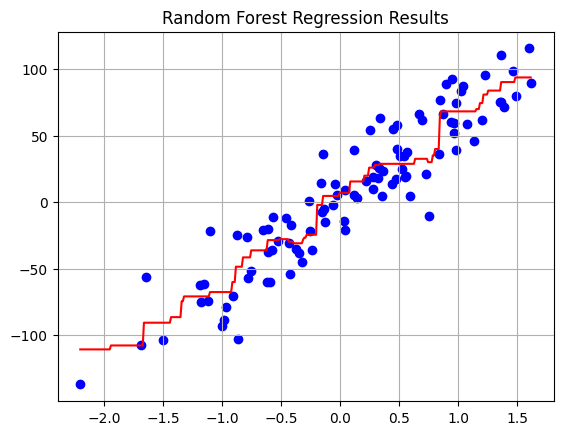

In [15]:
X_grid = np.arange(min(X),max(X),0.01)
X_grid = X_grid.reshape(len(X_grid),1)

plt.scatter(X,y, color='blue') #plotting real points
plt.plot(X_grid, rf_regressor.predict(X_grid),color='red') #plotting for predict points
plt.grid()
plt.title("Random Forest Regression Results")
plt.show()

In [16]:
oob_score = rf_regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score:.2f}')

Out-of-Bag Score: 0.81
